In [2]:

# imports
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import logging
from pathlib import Path
import pandas as pd

# Project imports
from auditory_prf.utils.cochlea_loader_functions import load_cochlea_results, organize_for_eachtone_allCFs


Found results directory: wav_40cf_128-128-128anf_psth_5files_20260224_185153
Found 5 .npz files

Loaded: sequence03_fc125hz_dur267ms_isi67ms_total5.0sec_numtones15
PSTH shape: (40, 5000)
Duration: 5.00 seconds


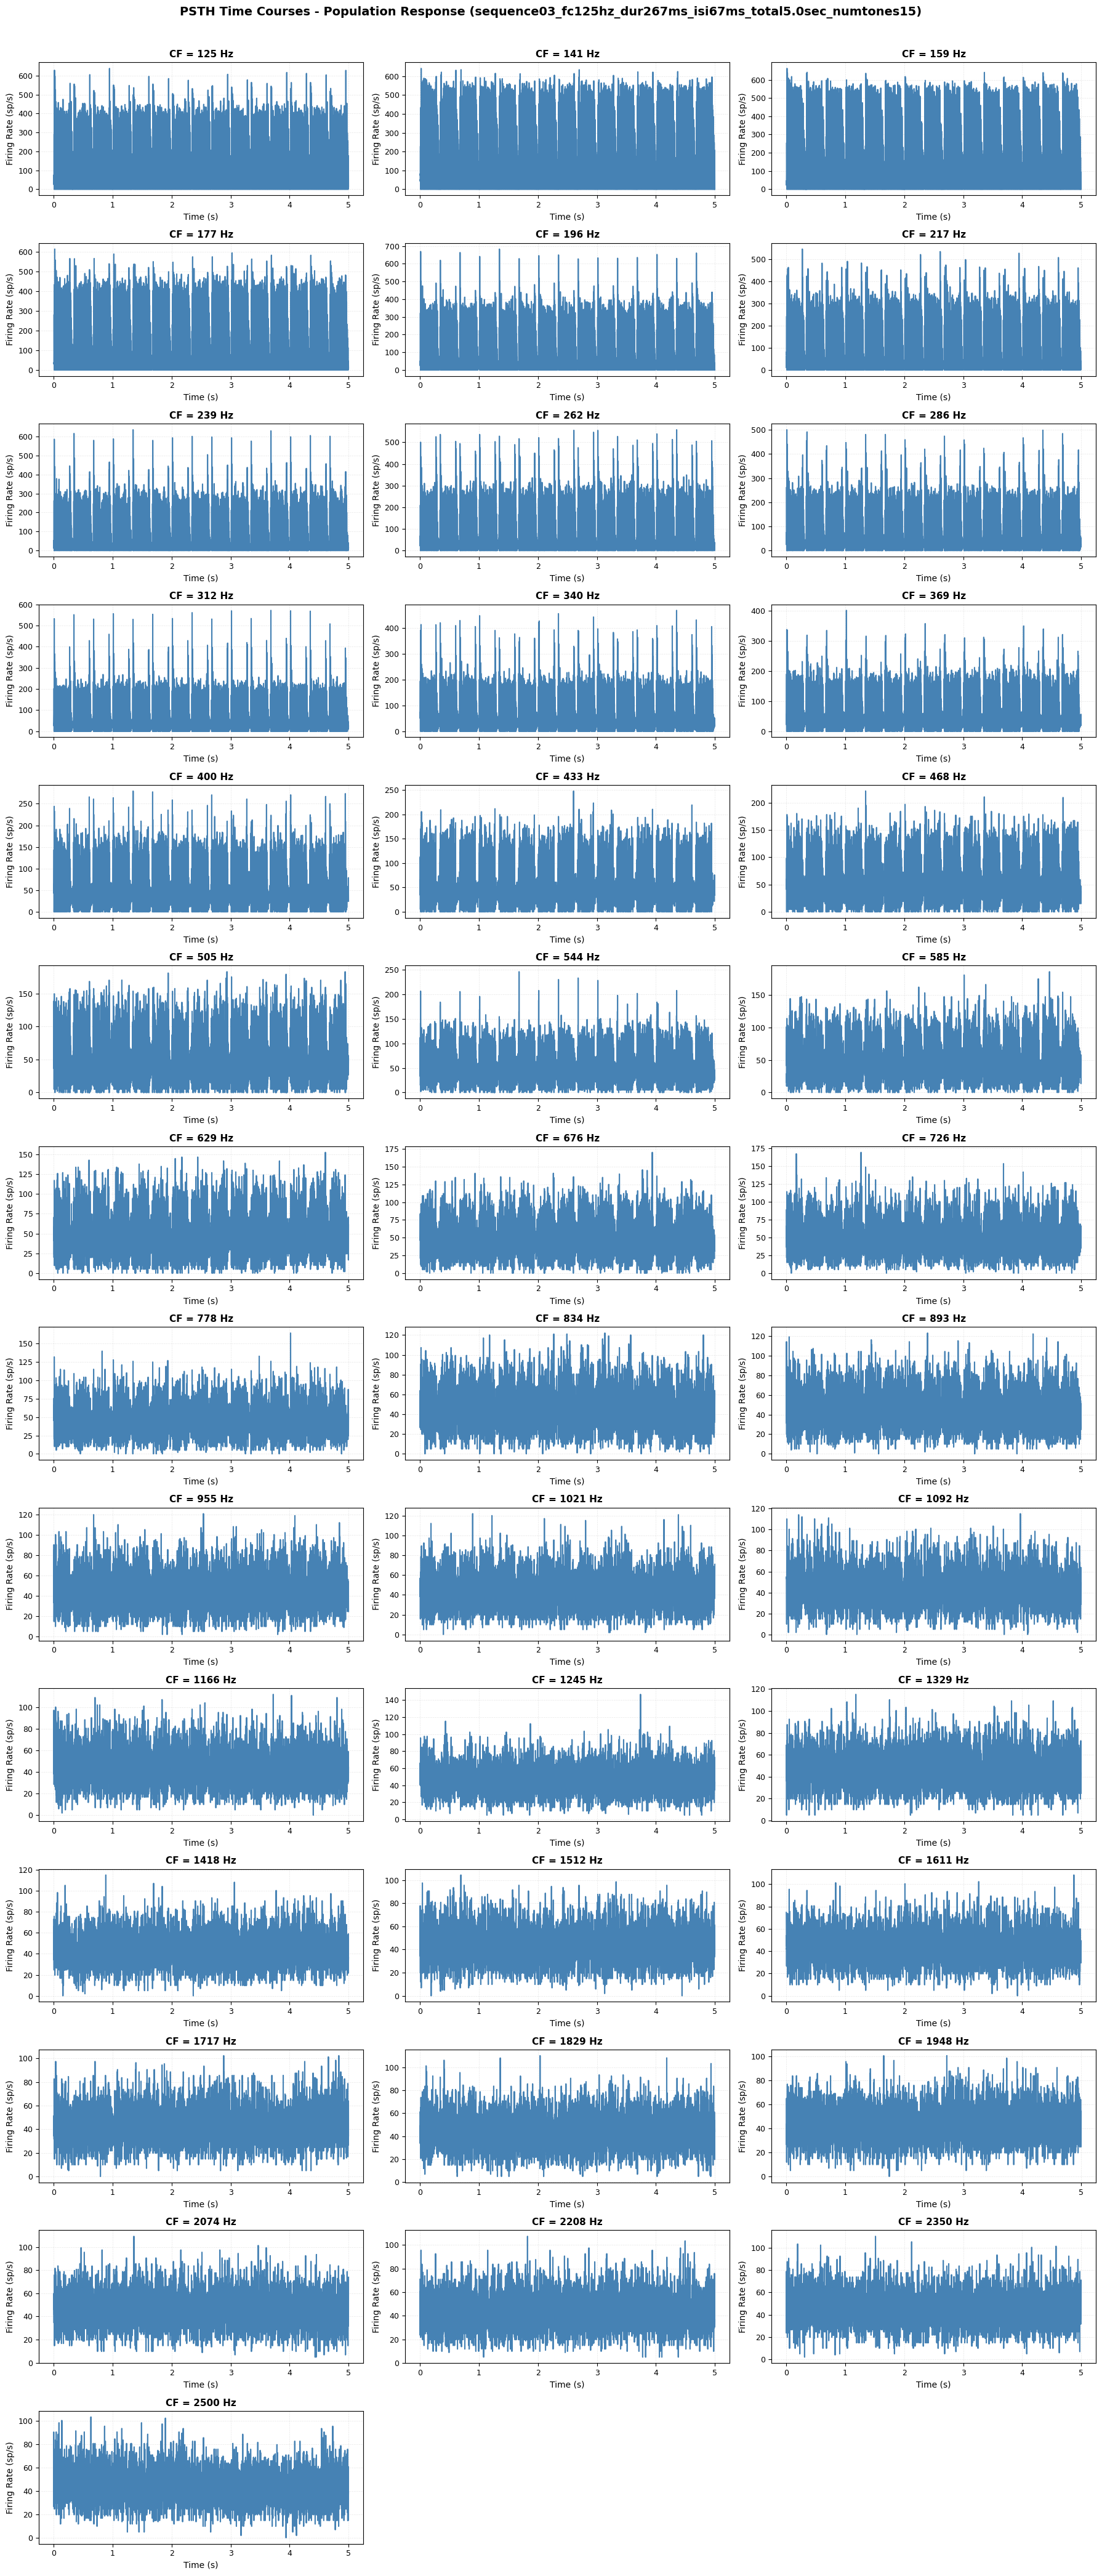

In [5]:
# ===== Load PSTH data from WAV simulation =====
from auditory_prf.utils.result_saver import ResultSaver
from auditory_prf.visualization.plot_cochlea_output import plot_psth_timecourses

# Specify base directory (update this path to your data)
base_dir = Path("./models_output/dipc_test_240226_02")

# Find the nested results folder (most recent subdirectory)
subdirs = [d for d in base_dir.iterdir() if d.is_dir()]
if not subdirs:
    raise FileNotFoundError(f"No subdirectories found in {base_dir}")

psth_results_dir = max(subdirs, key=lambda p: p.stat().st_mtime)
print(f"Found results directory: {psth_results_dir.name}")

# Load first file as example
saver = ResultSaver(psth_results_dir)
npz_files = list(psth_results_dir.glob('*.npz'))

if npz_files:
    print(f"Found {len(npz_files)} .npz files")

    # Load first file
    data = saver.load_npz(npz_files[0].name)

    # Extract data
    population_psth = data['population_rate_psth']
    time_axis = data['time_axis']
    cf_list_psth = data['cf_list']
    identifier = data.get('soundfileid', 'unknown')

    print(f"\nLoaded: {identifier}")
    print(f"PSTH shape: {population_psth.shape}")
    print(f"Duration: {time_axis[-1]:.2f} seconds")

    # Plot time courses
    fig, axes = plot_psth_timecourses(
        time_axis=time_axis,
        population_psth=population_psth,
        cf_list=cf_list_psth,
        identifier=identifier
    )

    plt.show()
else:
    print(f"No .npz files found in {psth_results_dir}")


Plotting all 5 stimuli


[1/5] Loading: dipc_sequence03_fc125hz_dur267ms_isi67ms_total5.0sec_numtones15.npz
    - PSTH shape: (40, 5000)
    - Duration: 5.00 seconds


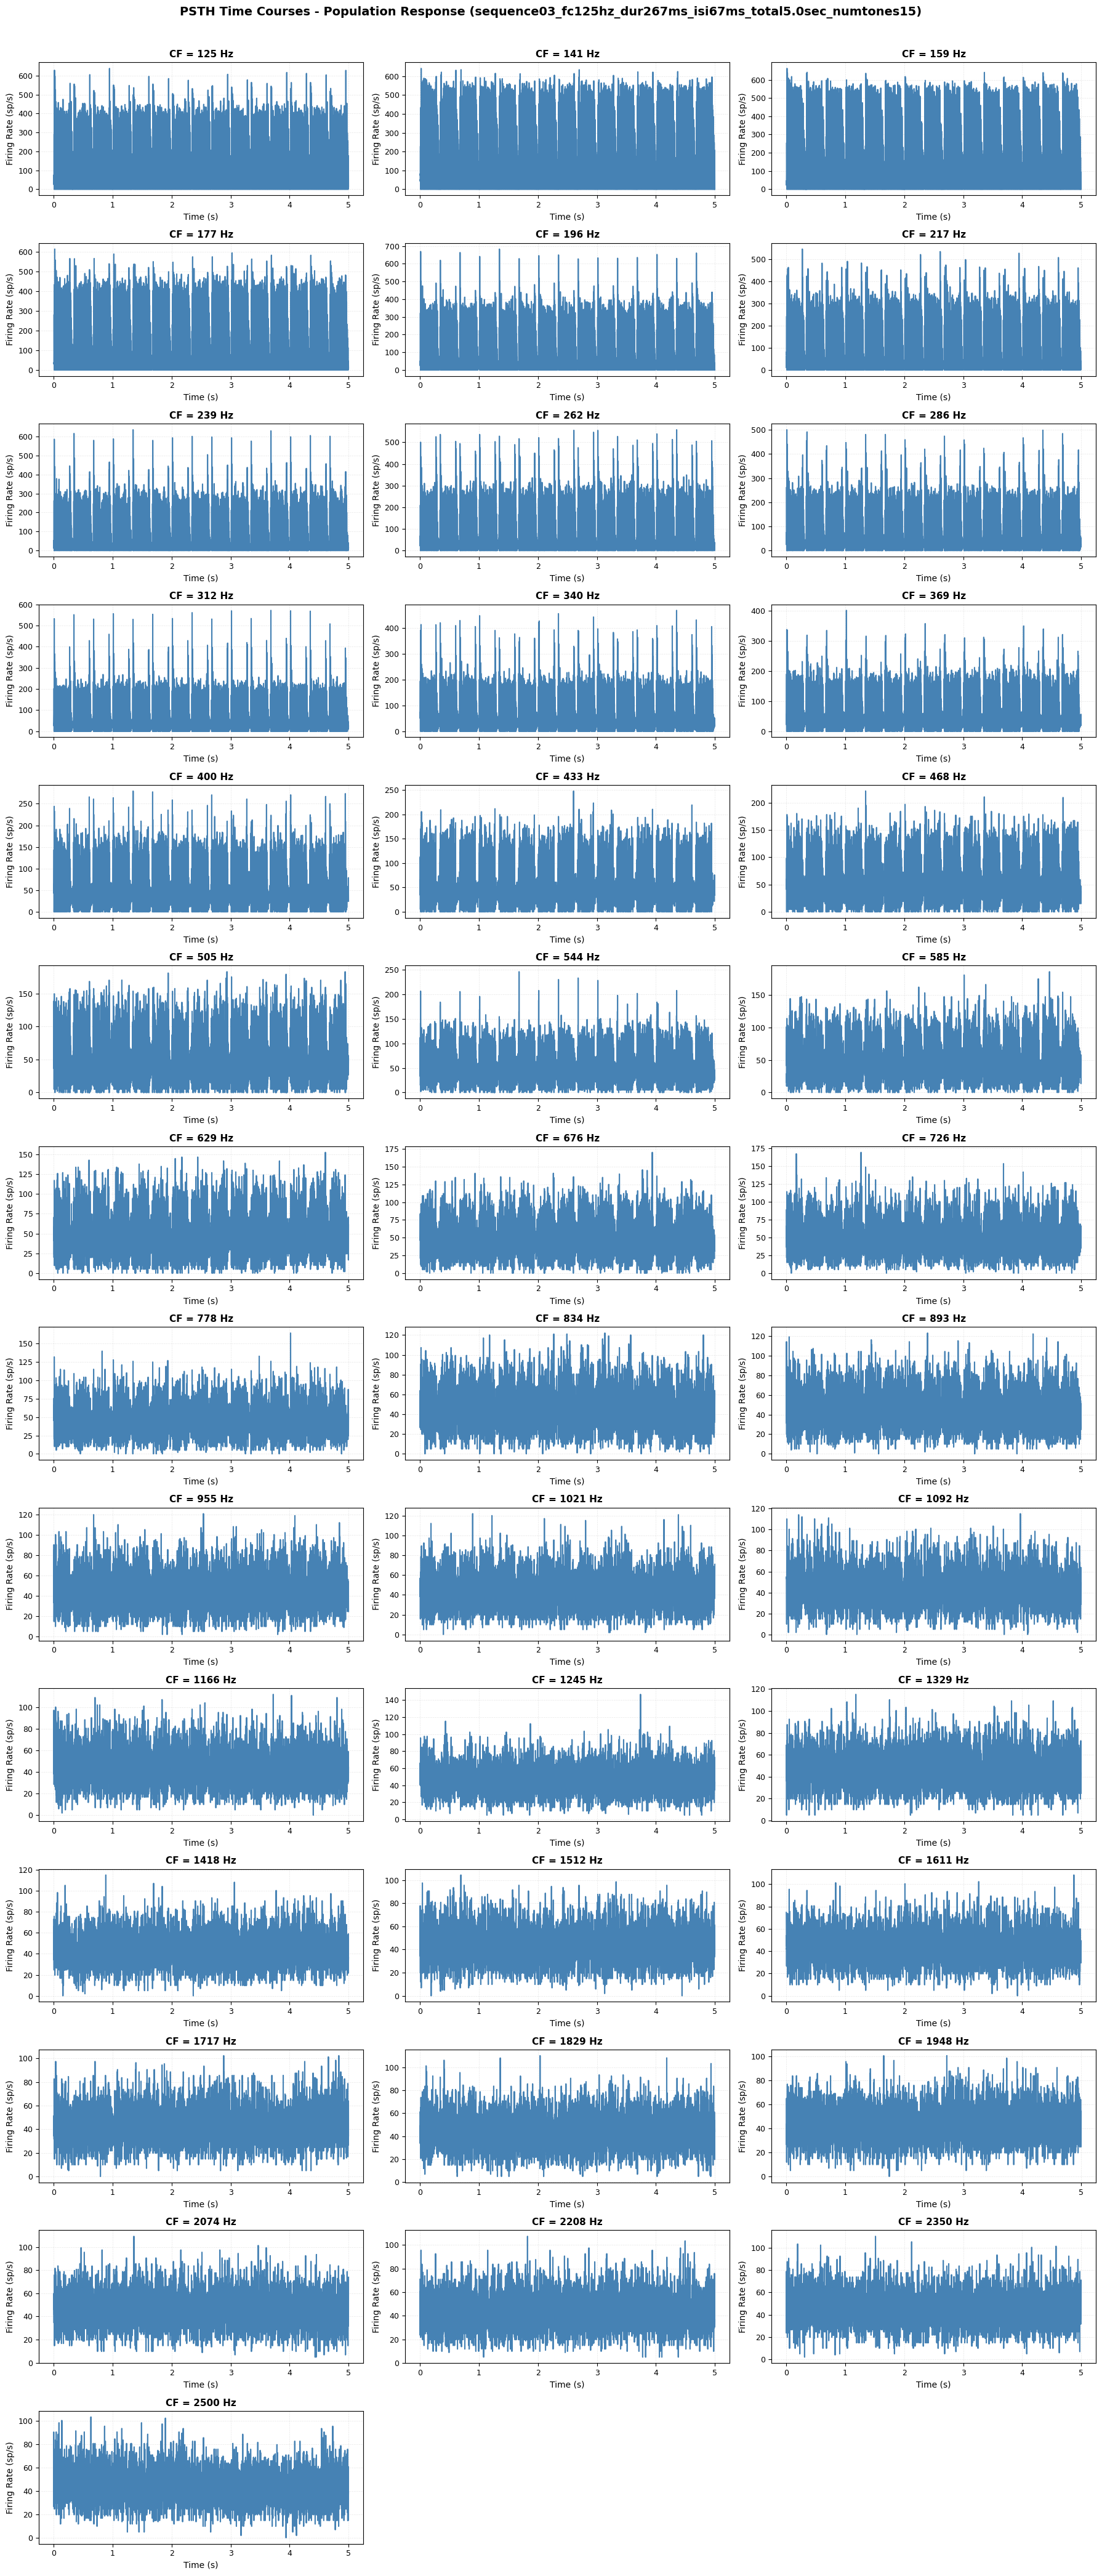


[2/5] Loading: dipc_sequence05_fc780hz_dur267ms_isi67ms_total5.0sec_numtones15.npz
    - PSTH shape: (40, 5000)
    - Duration: 5.00 seconds


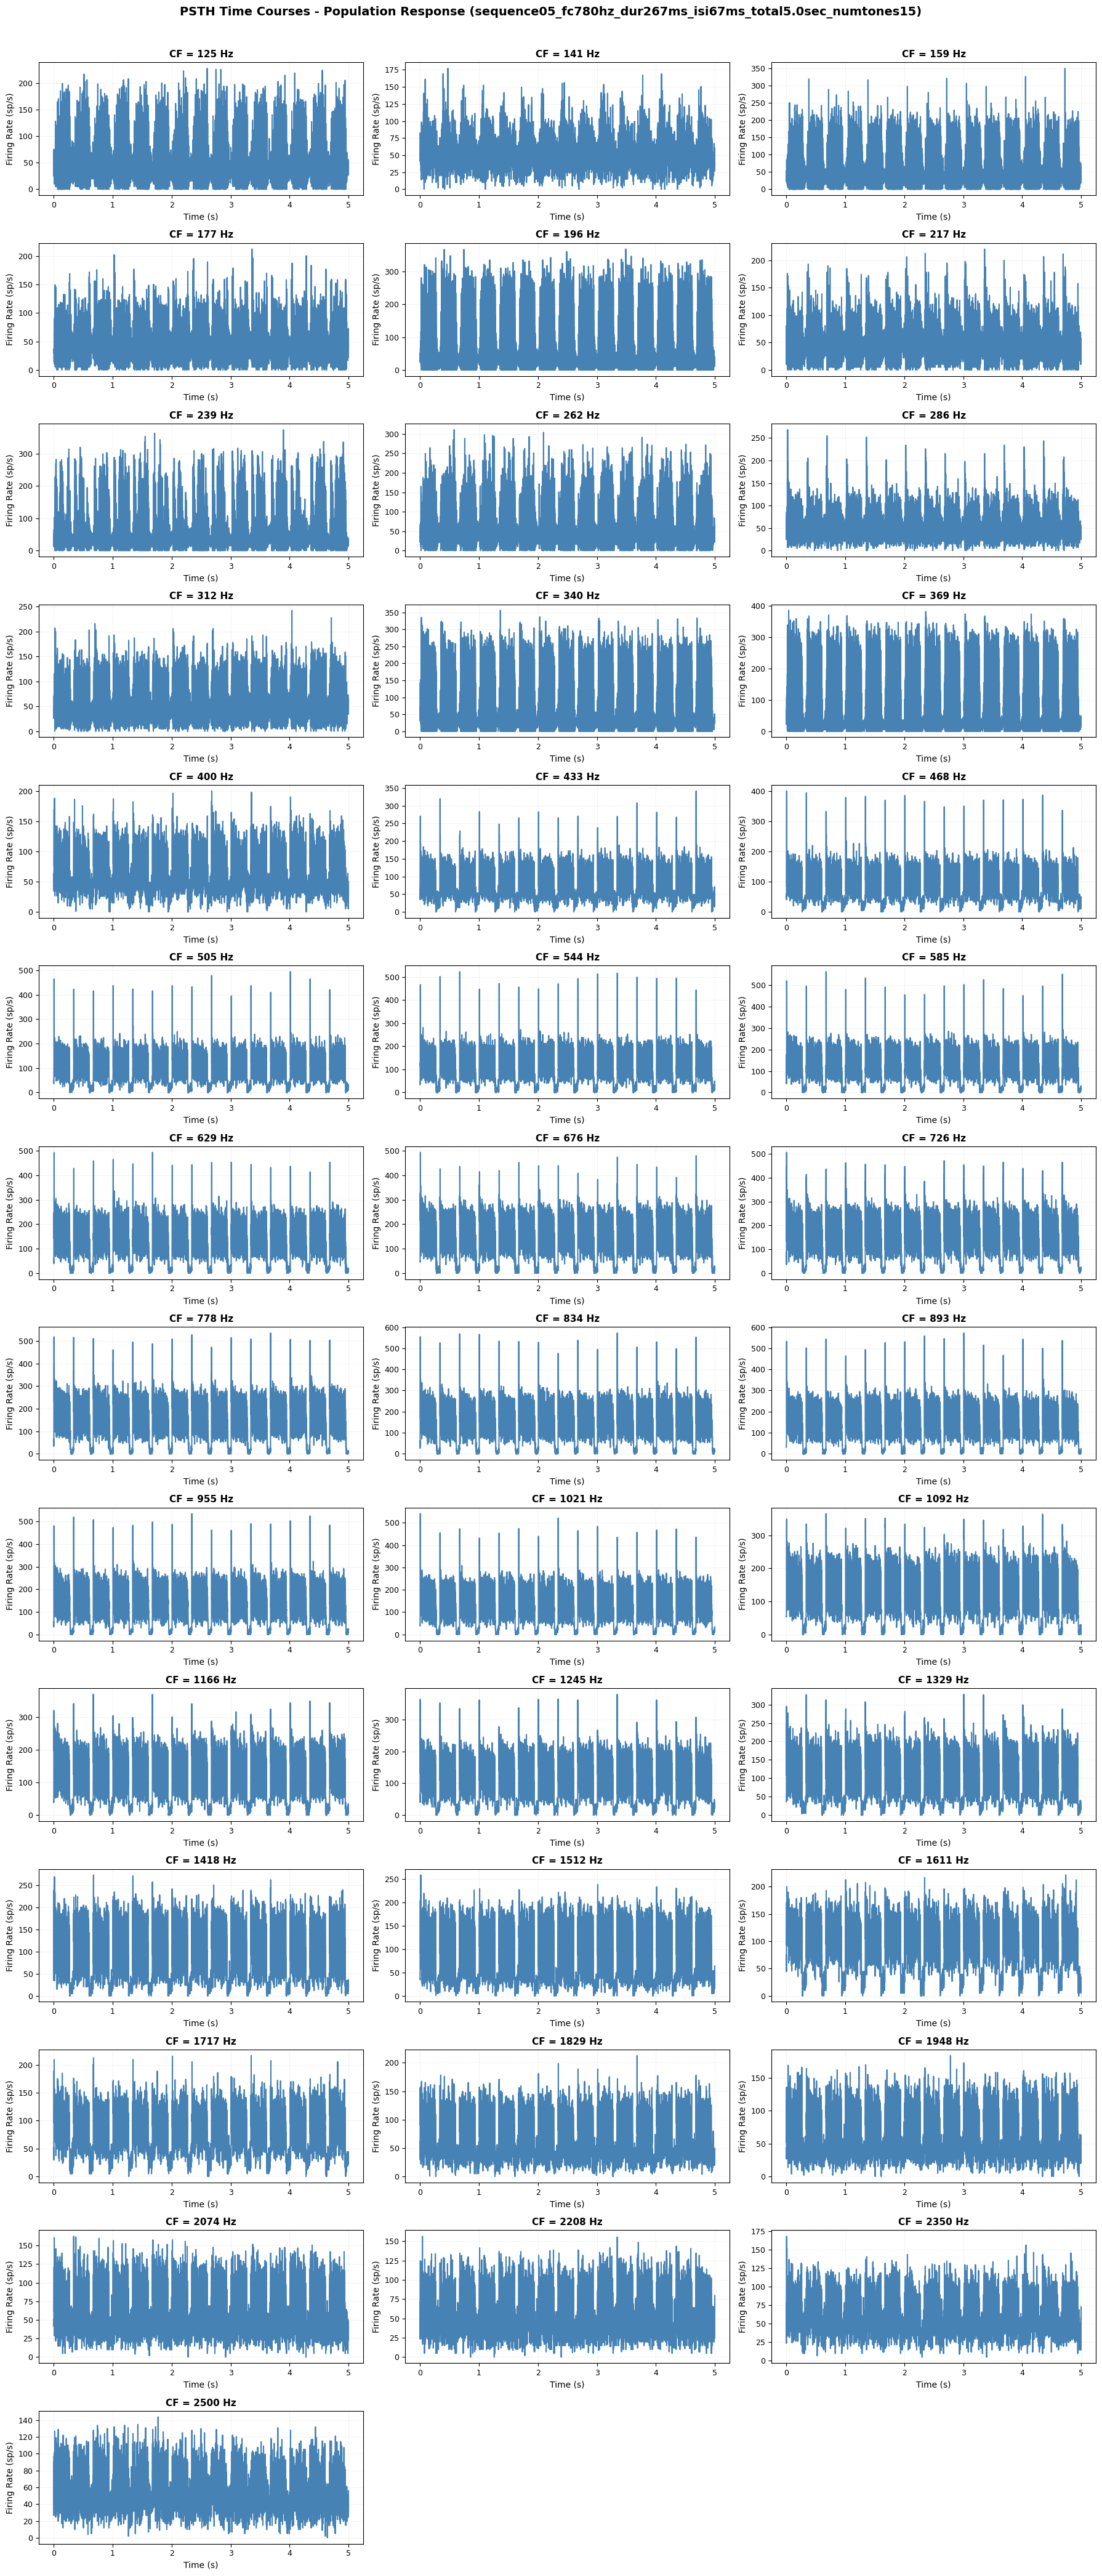


[3/5] Loading: dipc_sequence07_fc2500hz_dur267ms_isi67ms_total5.0sec_numtones15.npz
    - PSTH shape: (40, 5000)
    - Duration: 5.00 seconds


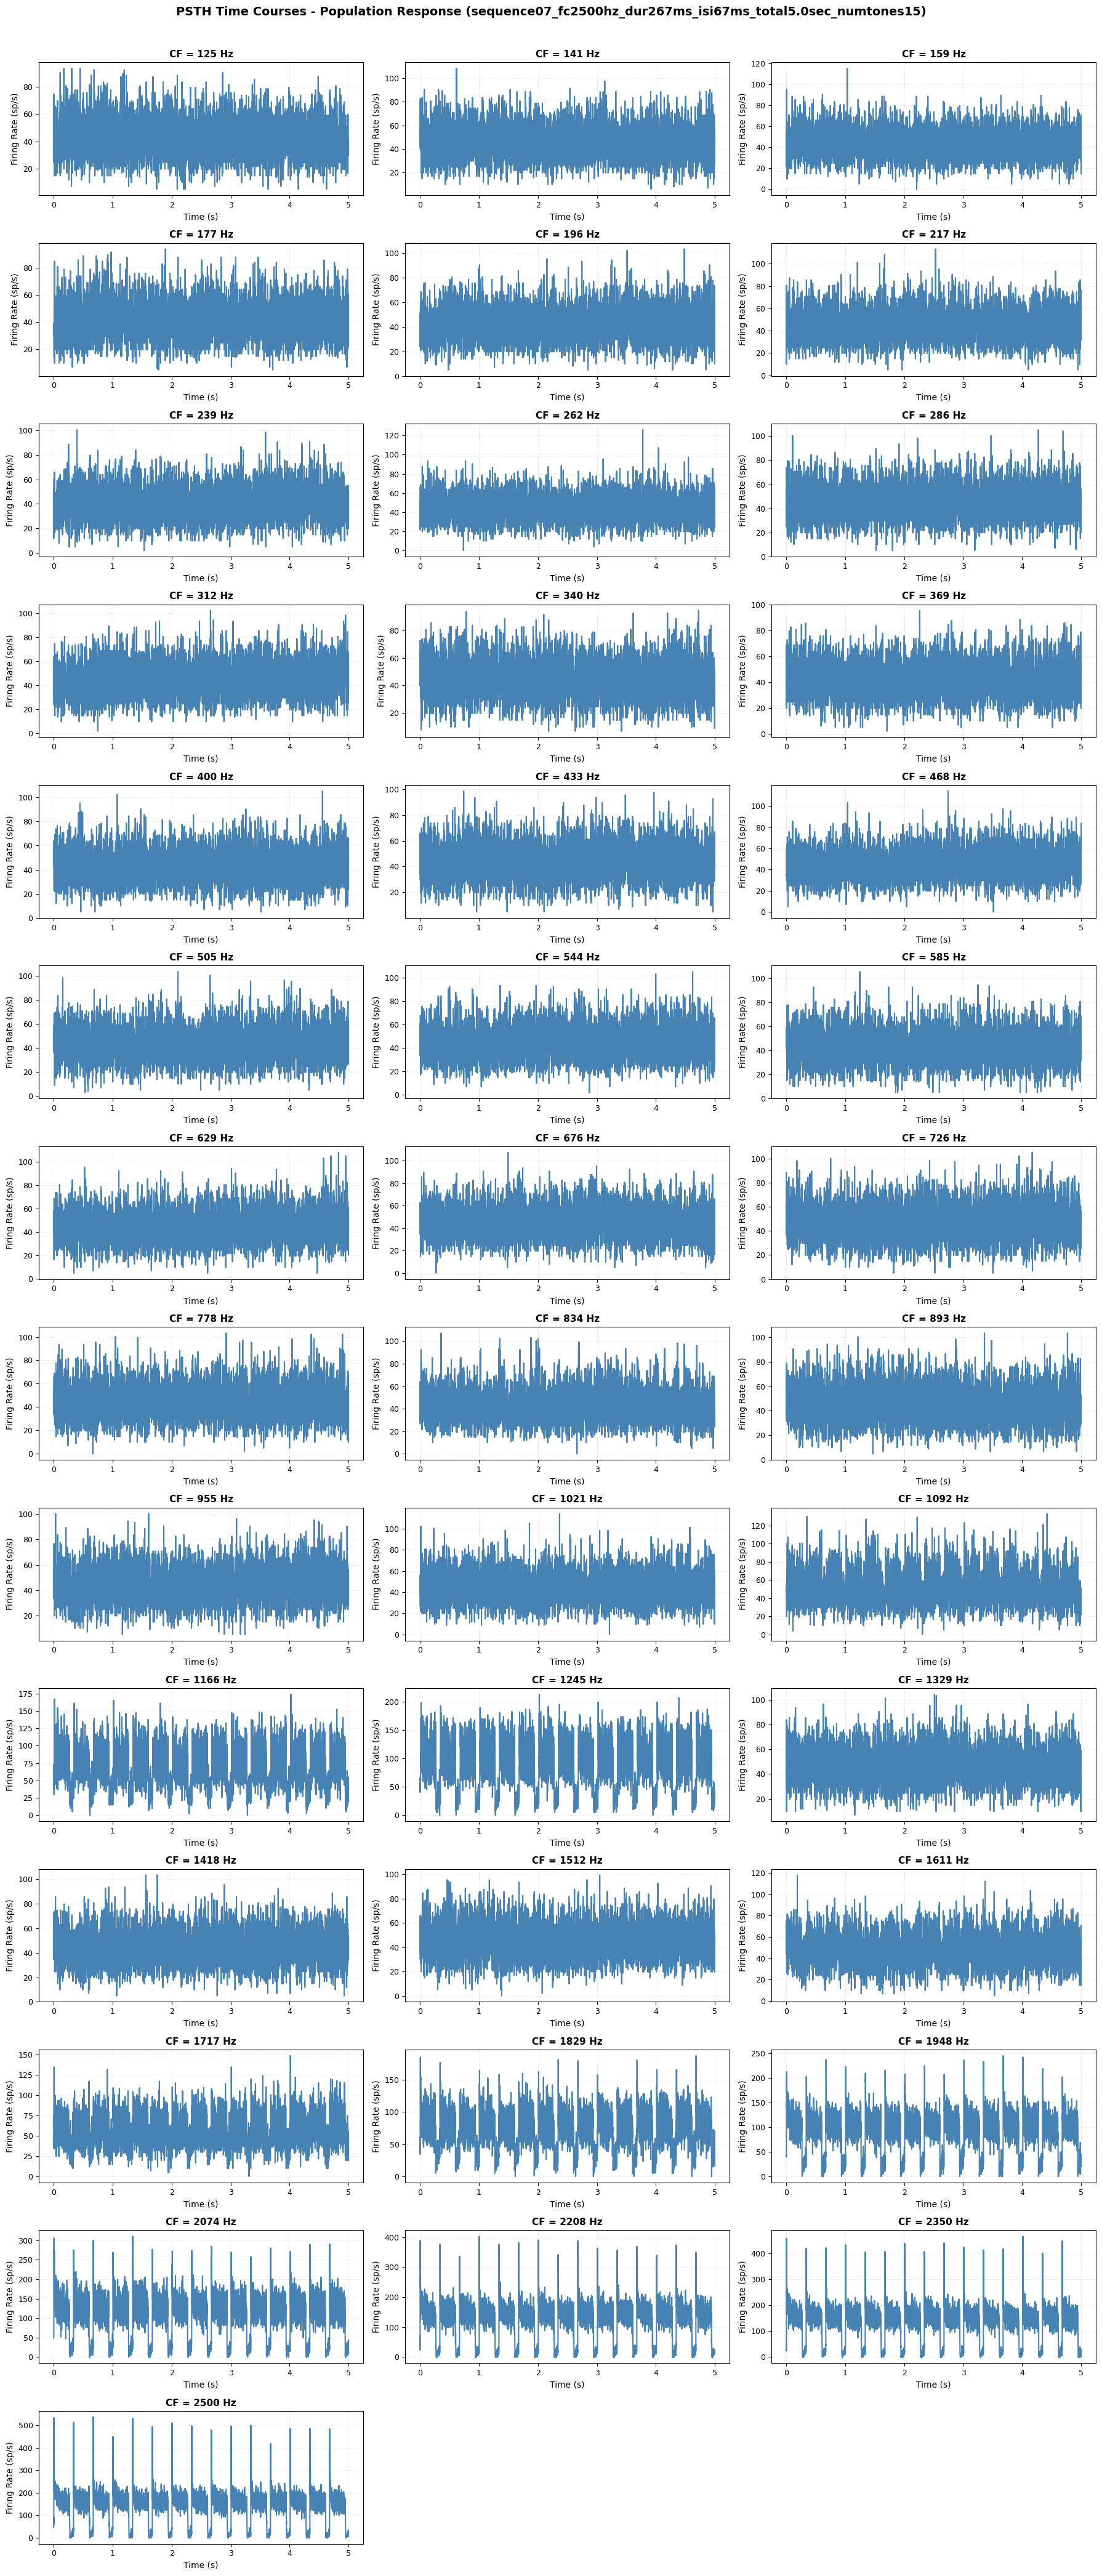


[4/5] Loading: dipc_sequence06_fc1350hz_dur267ms_isi67ms_total5.0sec_numtones15.npz
    - PSTH shape: (40, 5000)
    - Duration: 5.00 seconds


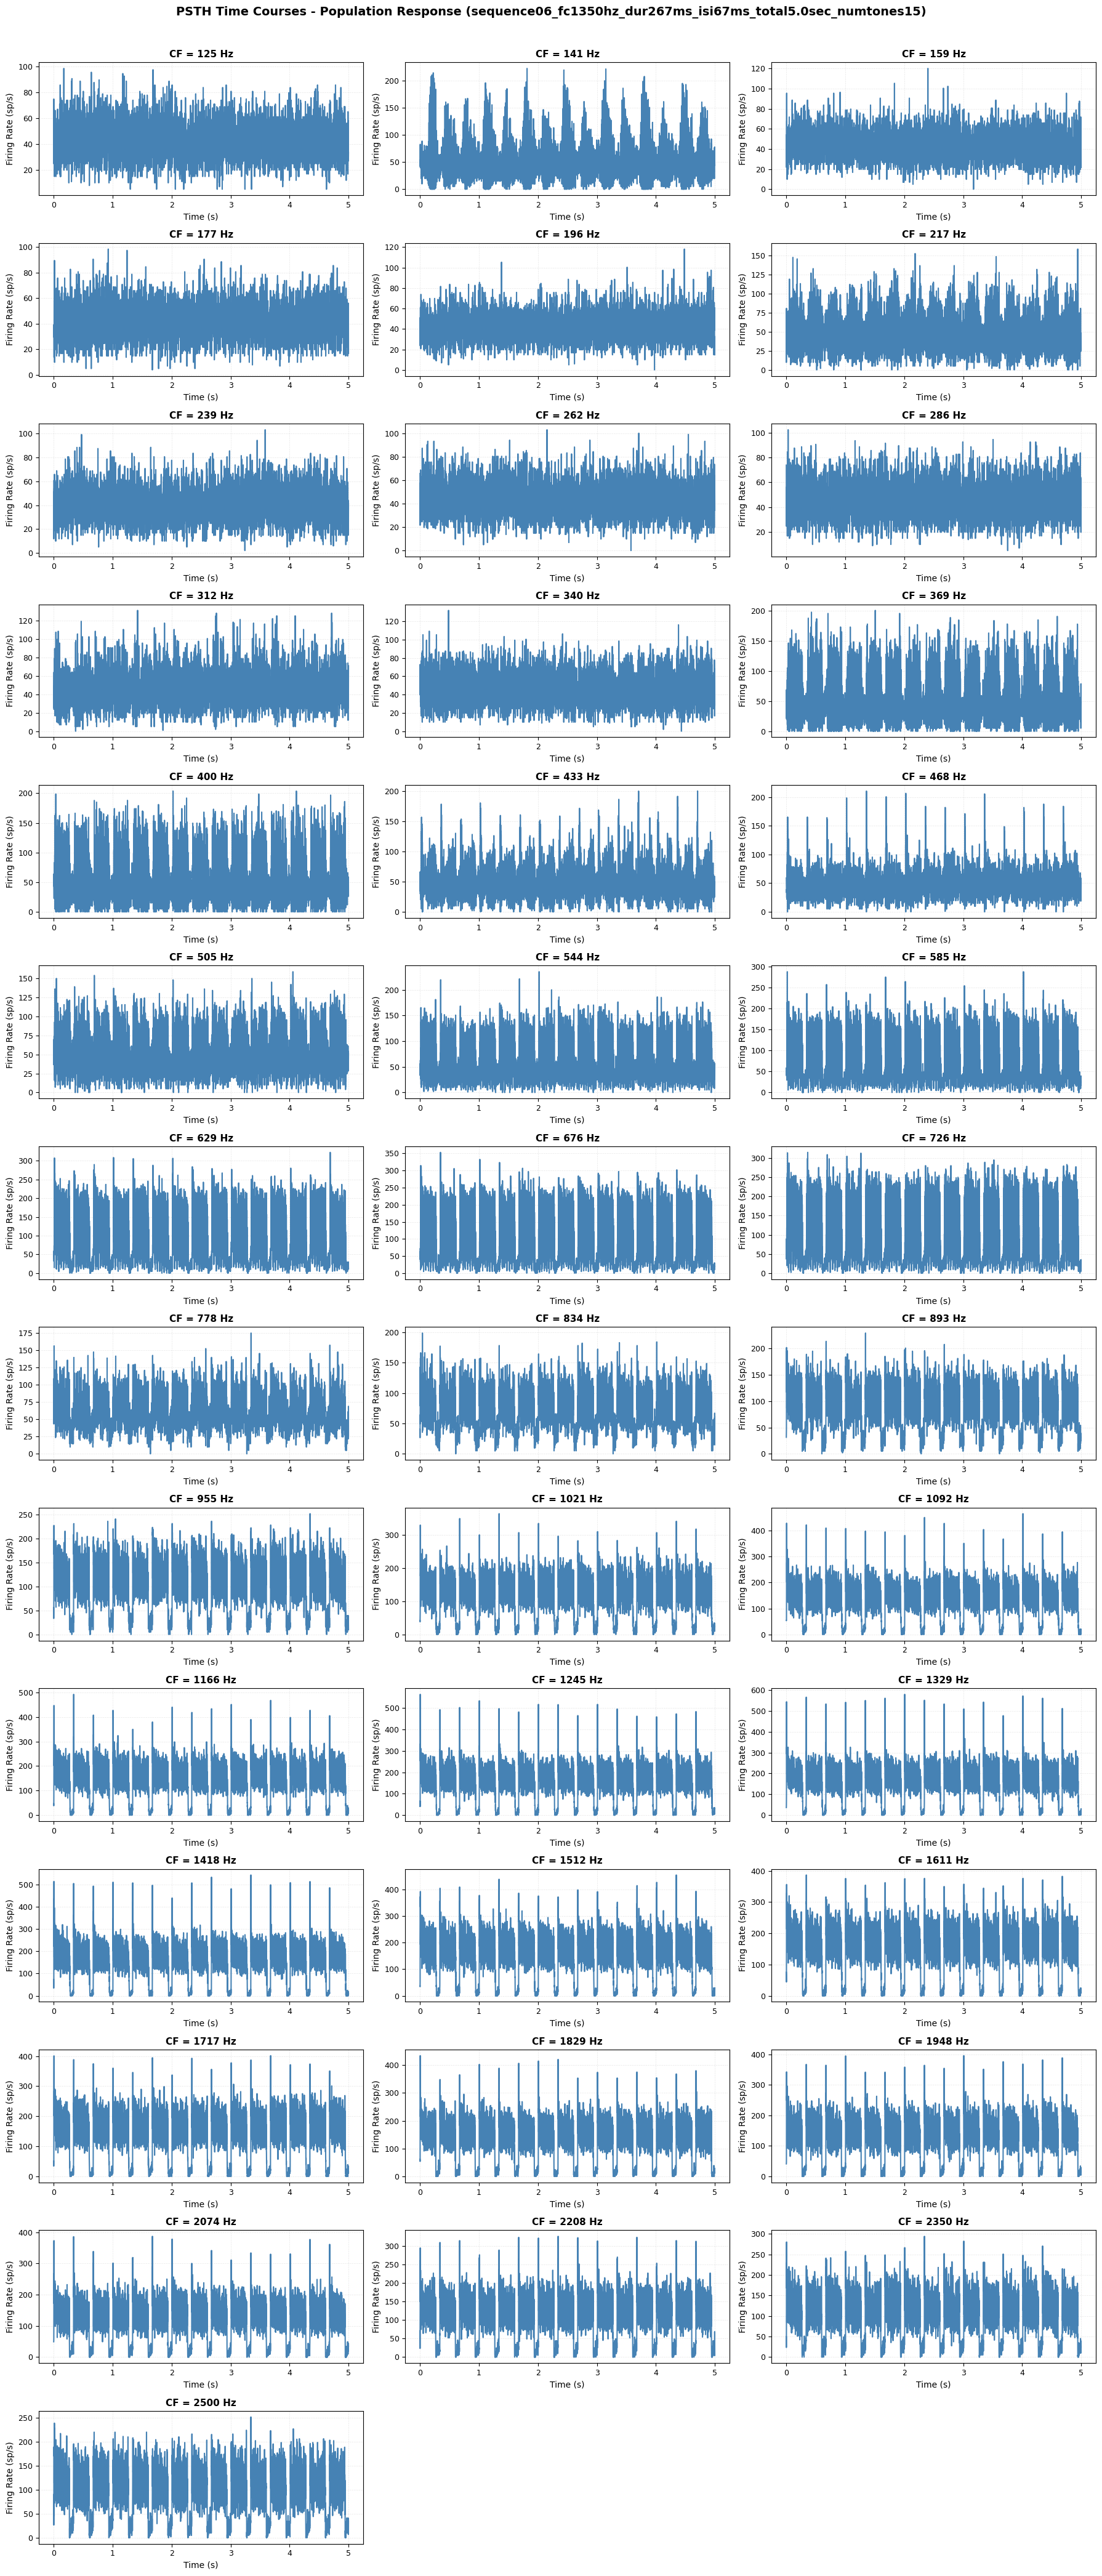


[5/5] Loading: dipc_sequence04_fc440hz_dur267ms_isi67ms_total5.0sec_numtones15.npz
    - PSTH shape: (40, 5000)
    - Duration: 5.00 seconds


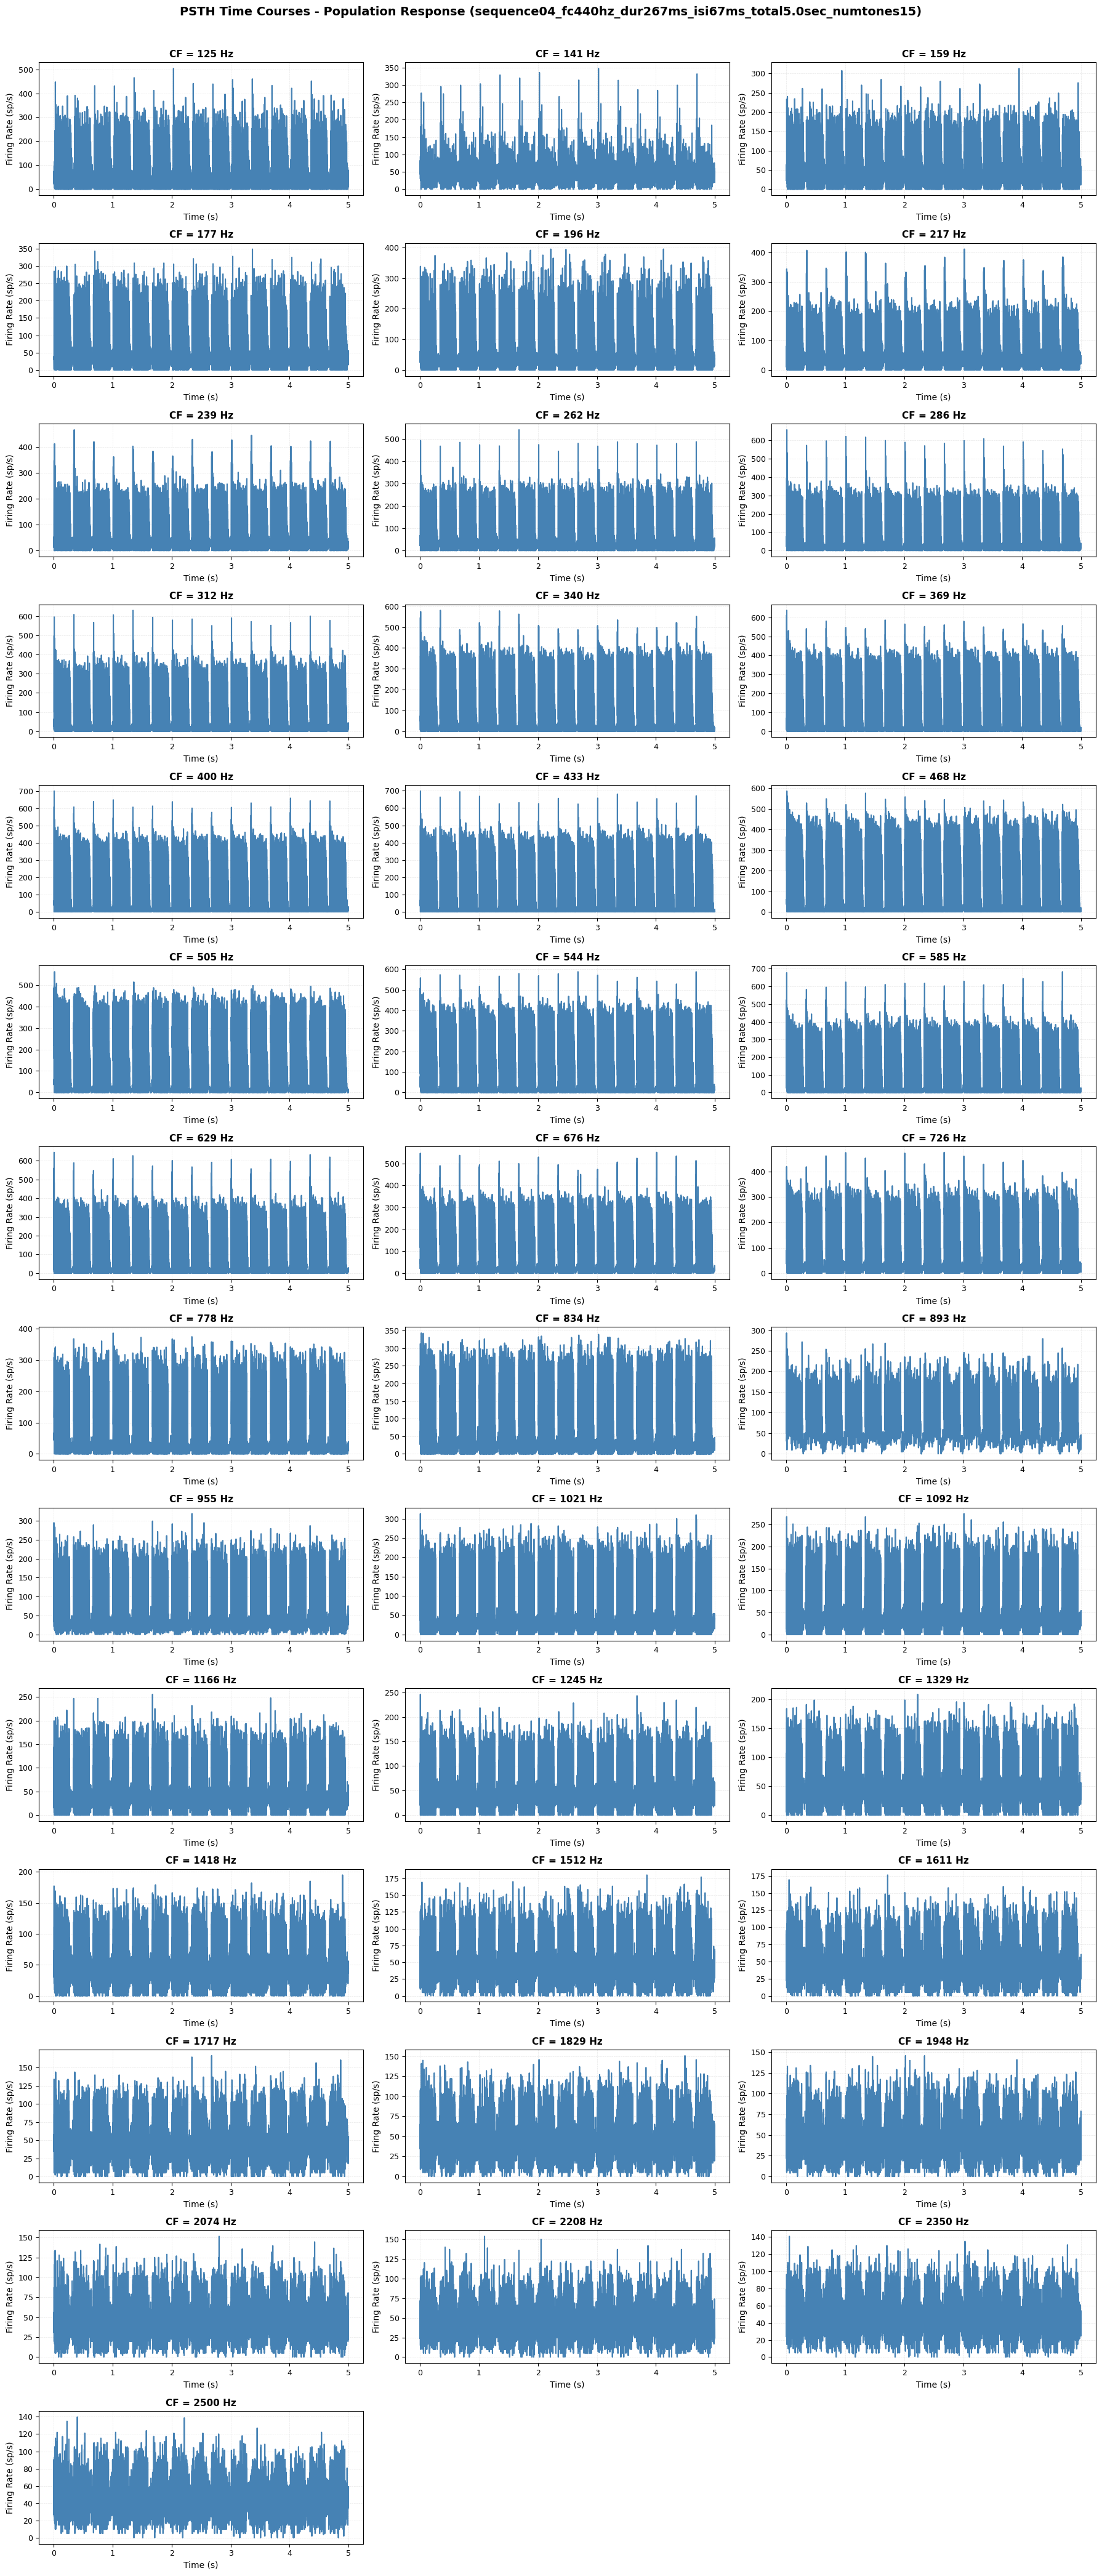


Completed plotting all stimuli


In [6]:
# ===== Plot ALL stimuli in the folder =====

print(f"\n{'='*60}")
print(f"Plotting all {len(npz_files)} stimuli")
print(f"{'='*60}\n")

for i, npz_file in enumerate(npz_files, 1):
    print(f"\n[{i}/{len(npz_files)}] Loading: {npz_file.name}")

    # Load data
    data = saver.load_npz(npz_file.name)

    # Extract data
    population_psth = data['population_rate_psth']
    time_axis = data['time_axis']
    cf_list_psth = data['cf_list']
    identifier = data.get('soundfileid', 'unknown')

    print(f"    - PSTH shape: {population_psth.shape}")
    print(f"    - Duration: {time_axis[-1]:.2f} seconds")

    # Plot time courses
    fig, axes = plot_psth_timecourses(
        time_axis=time_axis,
        population_psth=population_psth,
        cf_list=cf_list_psth,
        identifier=identifier
    )

    plt.show()

print(f"\n{'='*60}")
print(f"Completed plotting all stimuli")
print(f"{'='*60}")

In [ ]:

# ===== Plot per-CF time courses and save high-quality figures =====
from auditory_prf.visualization.plot_cochlea_output import plot_timecourse_per_cf

# Output directory: a sub-folder inside the results directory
per_cf_save_dir = psth_results_dir / "per_cf_timecourses"
print(f"Figures will be saved to: {per_cf_save_dir}\n")

for i, npz_file in enumerate(npz_files, 1):
    print(f"[{i}/{len(npz_files)}] {npz_file.name}")

    data = saver.load_npz(npz_file.name)
    population_psth = data['population_rate_psth']
    time_axis       = data['time_axis']
    cf_list_psth    = data['cf_list']
    identifier      = str(data.get('soundfileid', npz_file.stem))

    figs = plot_timecourse_per_cf(
        time_axis      = time_axis,
        population_psth= population_psth,
        cf_list        = cf_list_psth,
        identifier     = identifier,
        save_dir       = per_cf_save_dir,
        dpi            = 300,
        figsize        = (18, 4),
    )

    # Close figures to free memory after saving
    for fig in figs:
        plt.close(fig)

print(f"\nDone. {len(npz_files) * len(cf_list_psth)} figures saved to:\n  {per_cf_save_dir}")
